# **Amazon  product Sales analysis **

Problem Statement :

# The objective of this project is to analyze Amazon product data to identify trends in pricing, discounts, customer ratings, and product categories, and derive business insights through data analysis.





**Import libraries + Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("amazon.csv")
df.head()
df.info()
df.isnull().sum() # count missing value per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


📦 Total Products: 1464

⭐ Average Rating: 4.1

💰 Average Discount: 47%

# 🛒 Total Categories: 9

**Clean the Data**

In [5]:
# --- 1. CLEANING THE PRICE COLUMNS ---
# This removes any currency symbols, spaces, or commas, keeping only numbers and decimals.
df['discounted_price'] = df['discounted_price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

df['actual_price'] = df['actual_price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

# --- 2. CLEANING THE DISCOUNT PERCENTAGE ---
# This strips away the '%' sign and turns the column into numbers.
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

# --- 3. CLEANING RATINGS & COUNTS ---
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# --- 4. DROPPING MISSING DATA & DUPLICATES ---
df = df.dropna(subset=['rating'])
df = df.drop_duplicates()

# --- 5. SPLITTING THE CATEGORY ---
df['main_category'] = df['category'].str.split('|').str[0]

# --- 6. CHECKING THE RESULTS ---
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1464 non-null   object 
 1   product_name         1464 non-null   object 
 2   category             1464 non-null   object 
 3   discounted_price     1464 non-null   float64
 4   actual_price         1464 non-null   float64
 5   discount_percentage  1464 non-null   int64  
 6   rating               1464 non-null   float64
 7   rating_count         1462 non-null   float64
 8   about_product        1464 non-null   object 
 9   user_id              1464 non-null   object 
 10  user_name            1464 non-null   object 
 11  review_id            1464 non-null   object 
 12  review_title         1464 non-null   object 
 13  review_content       1464 non-null   object 
 14  img_link             1464 non-null   object 
 15  product_link         1464 non-null   object

# Explore - Answer Buisness Questions

In [7]:
# Q1 : What are the most common product categories ?
print(df['main_category'].value_counts().head(10))
# Q2 : Which categories have the highest customer rating?
print(df.groupby('main_category')['rating'].mean().sort_values(ascending = False).head(10))
# Q3: Which categories have the the highest average discount ?
print(df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending = False).head(10))
# Q4: Does a bigger discount lead to a better rating ?
print(df[['discount_percentage' , 'rating']].corr())
# Q5: Which products have the most reviews?
print(df[['product_name' , 'rating_count']].sort_values('rating_count', ascending = False).head(10))
#Q6: Which categories get the biggest price drop(actual price - discounted price) ?
df['price_drop'] = df['actual_price'] - df['discounted_price']
print(df.groupby('main_category')['price_drop'].mean().sort_values(ascending = False).head(10))


main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64
main_category
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040716
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64
main_category
HomeImprovement          57.500000
Computers&Accessories    54.024283
Health&PersonalCare      53.000000
Electronics              50.828897
MusicalInstruments       46.000000
Car&Motorbike            42.000000
Home&Kitchen             40.174497
OfficeProducts           12.354839
Toys&Games                0.000000
Name: discount_percen

# Visualize - Turn numbers into charts

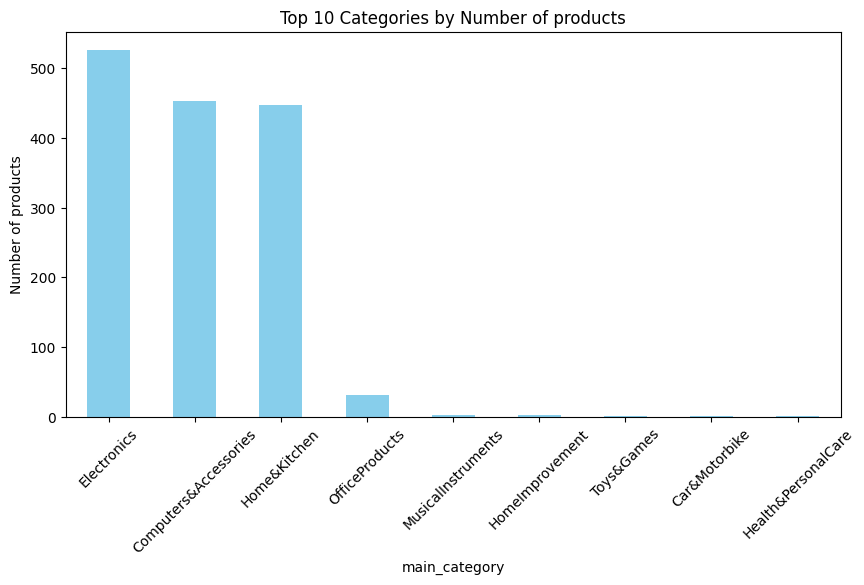

In [10]:
# Chart 1 : Top categories by number of products
plt.figure(figsize=(10,5))
df['main_category'].value_counts().head(10).plot(kind = 'bar' , color = 'skyblue')
plt.title('Top 10 Categories by Number of products')
plt.ylabel('Number of products')
plt.xticks(rotation = 45)
plt.show()

##  Electronics, Computers & Accessories, and Home & Kitchen contain the highest number of products, showing that these categories dominate the dataset.**

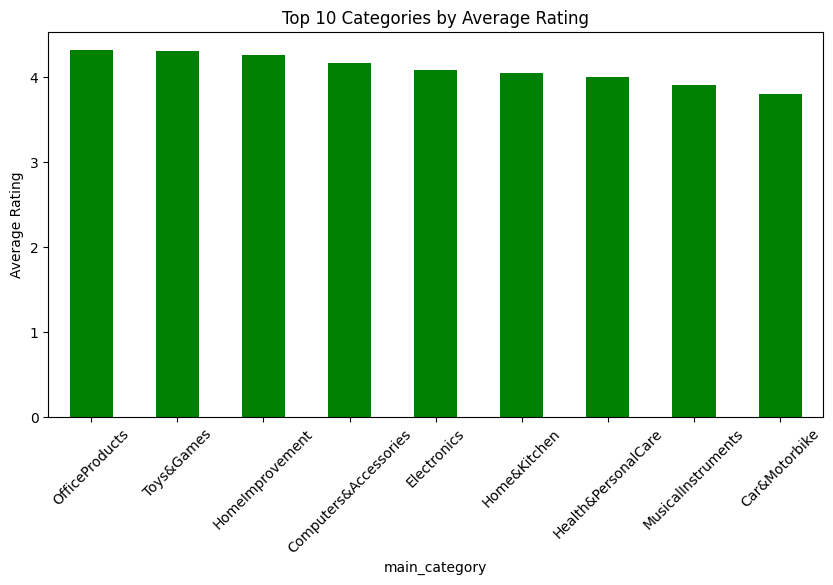

In [11]:
# Chart 2 : Top categories by average rating
plt.figure(figsize=(10,5))
df.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Top 10 Categories by Average Rating')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

# Office Products and Toys & Games have the highest average ratings. However, these categories contain fewer products, so the averages should be interpreted with caution.

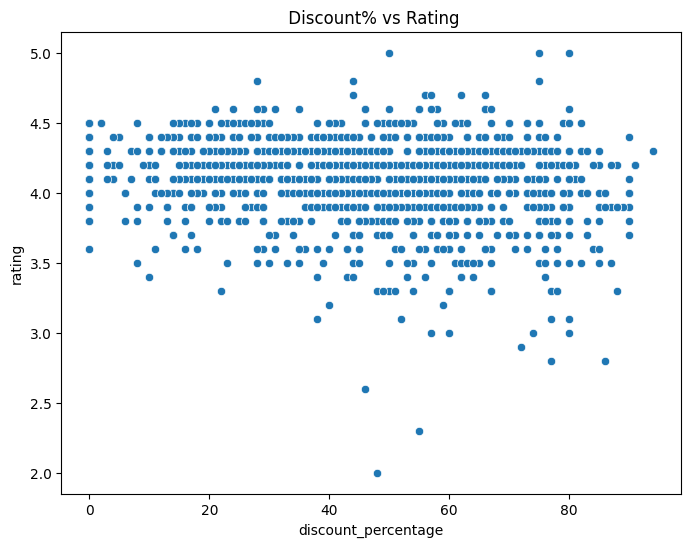

In [14]:
 # Chart 3 : Discount% vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot ( data = df ,x  ='discount_percentage' , y ='rating')
plt.title(' Discount% vs Rating')
plt.show()

# There is no clear relationship between higher discounts and better customer ratings. This suggests that product quality has a greater influence on customer satisfaction than discounts.

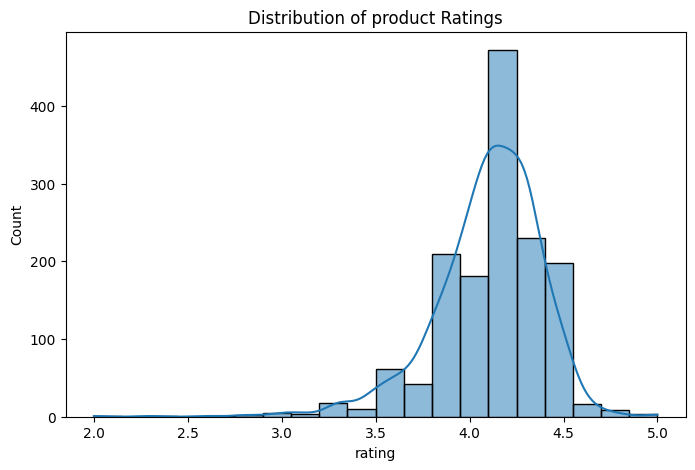

In [12]:
# chart 4 : Distribution of rating overall
plt.figure(figsize = (8,5))
sns.histplot(df['rating'], bins = 20 , kde = True)
plt.title('Distribution of product Ratings')
plt.show()

# Actual Price and Discounted Price show a very strong positive correlation, while Discount Percentage has only a weak negative correlation with Rating.

# Extra Analysis

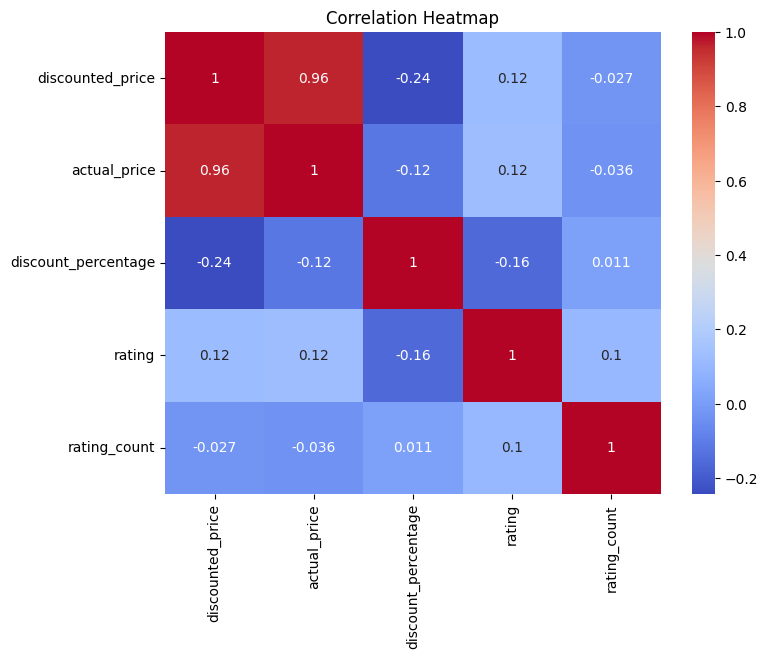

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].corr(),
    annot=True, cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# Most products have ratings between 4.0 and 4.4, indicating that the majority of products receive positive customer feedback.

**Buisness Recommendations**

Amazon should focus on maintaining product quality instead of relying only on heavy discounts, as discounts have little influence on customer ratings.

Categories with consistently high ratings can be highlighted in promotional campaigns to improve customer trust.


Products receiving large discounts but lower ratings should be reviewed for quality improvement rather than additional price reductions.



## Key Takeaways

- Cleaned and preprocessed a dataset containing 1,464 Amazon products using Pandas.
- Converted price, discount, rating, and review count columns into appropriate numeric formats.
- Performed Exploratory Data Analysis (EDA) to understand product categories, discounts, customer ratings, and pricing trends.
- Created data visualizations using Matplotlib and Seaborn, including bar charts, scatter plots, histograms, and a correlation heatmap.
- Derived business insights and recommendations from the analysis.
# - Strengthened my skills in Python, Pandas, NumPy, Matplotlib, Seaborn, data cleaning, and data visualization.

# **This analysis explored customer ratings, pricing, discounts, and product categories from Amazon product data. The findings suggest that customer satisfaction is driven more by product quality than discount percentage. Electronics and Computers dominate the marketplace, while several smaller categories achieve the highest average ratings. These insights can help businesses improve pricing strategies, marketing campaigns, and customer experience.**